In [35]:
!pip install matplotlib
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
x=np.linspace(0,10,100)
y=np.e**(np.sin(x)+np.cos(x))


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Kushagra\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [36]:
def lowess(x,y,f=0.3):
    n=len(x)
    y_pred=np.zeros(n)
    for i in range(n):
        distance=np.abs(x-x[i])
        h=np.sort(distance)[int(f*n)]
        w=(1-(distance/h)**3)**3
        w[distance>h]=0
        W=np.diag(w)
        X=np.vstack([np.ones(n),x]).T
        b=np.linalg.inv(X.T@W@X)@X.T@W@y
        y_pred[i]=b[0]+b[1]*x[i]
    return y_pred

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Kushagra\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


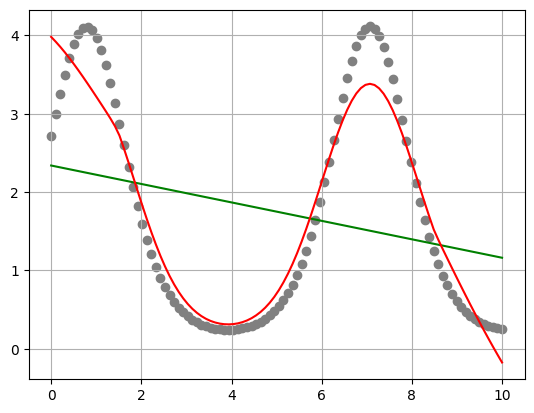

In [37]:
!pip install scikit-learn
from sklearn import linear_model
regr=linear_model.LinearRegression()
regr.fit(x.reshape(-1,1),y)
coef=regr.coef_[0]
inc=regr.intercept_
y_pred=regr.predict(x.reshape(-1,1))
y_lowess=lowess(x,y,f=0.3)
plt.scatter(x,y,color="grey")
plt.grid(1)
plt.plot(x,y_pred,color="green")
plt.plot(x,y_lowess,color="red")
plt.show()